# Order Gene set for deconvolution
February 19, 2024



## Raw data PTR analysis
we will do an initial search through the gene set, to identify genes with cycling chromatin in our predefined bins.

The idea would be that the top k bins have high PTR values then the chromatin may be cycling and we can place at a higher priority to deconvolve.

## Spellman genes

Use the set of Spellman genes to prioritize which genes to deconvolve.



In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

gene_name = 'CLB2'
config1 = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_gene(gene_name, 1)

Loading MNase reads for CLB2...Done.


In [3]:
chromatin_model.create_deconvolution_bins(smoothing=False)

Unflattened the input data is of shape: (16, 16, 50)
The size of our input data, G is: (16, 800)


In [16]:
image_shape = chromatin_model.deconv_hist_unflattened.shape[1:]
image_shape

(16, 50)

In [29]:
import pywt 

from src.wavelets_2d_linalg import create_wavelet2d_convolution_matrices

wavelet = pywt.Wavelet('bior4.4')

G_shape = chromatin_model.G.shape
decomp_mats, reconst_mats = create_wavelet2d_convolution_matrices(wavelet, image_shape, kron=True)


In [30]:
decomp_mats[0].shape

(800, 400)

In [31]:
reconst_mats[0].shape

(400, 800)

In [38]:
LL_decomp_G = G@decomp_mats[0]
LL_reconst_G = LL_decomp_G@reconst_mats[0]

LL_reconst_G.shape

(16, 800)

In [45]:
G_reconst_imgs = LL_reconst_G.reshape((G.shape[0], *image_shape))

G_reconst_imgs.shape

(16, 16, 50)

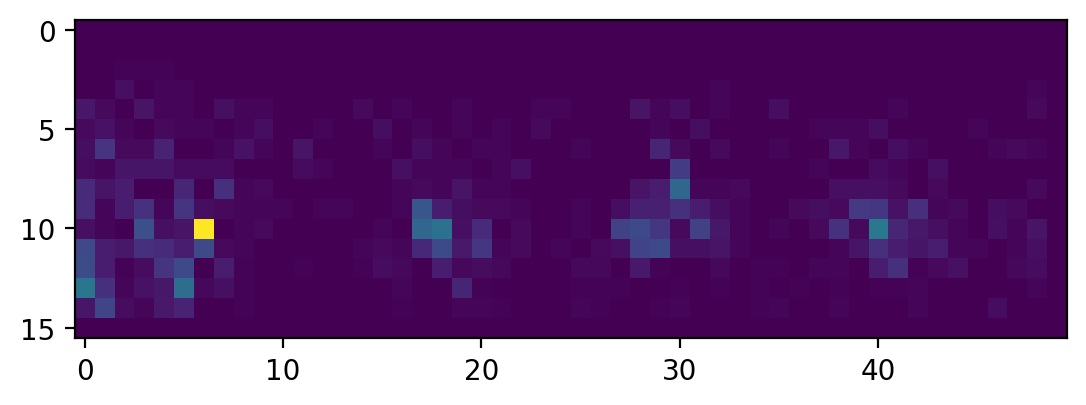

In [48]:
G_imgs = chromatin_model.deconv_hist_unflattened
plt.imshow(G_imgs[0])

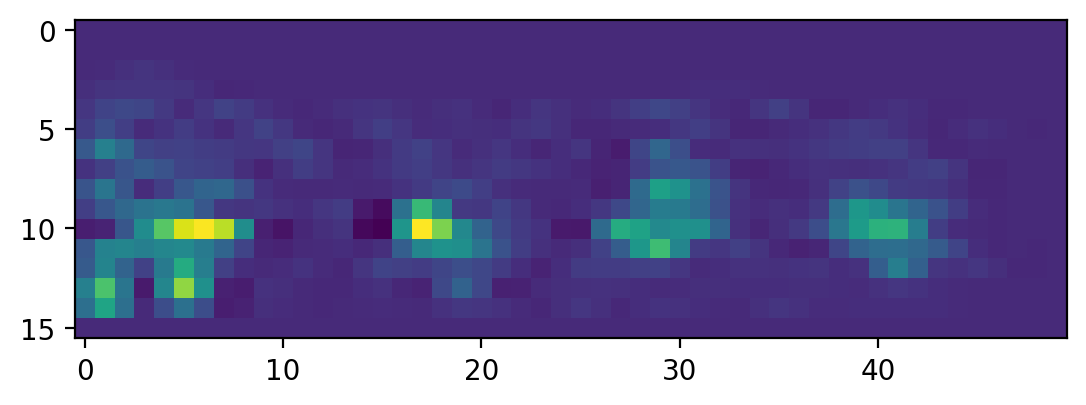

In [46]:
plt.imshow(G_reconst_imgs[0])